# Notebook 1 — Foundations and Sanity Checks

**Goal**: Verify the implementation is correct and visually demonstrate the DDPM vs DDIM difference at a fixed seed.

**Paper equations tested**:
- Ho et al. 2020, Eq. 4: forward process `q(x_t|x_0) = N(√α_t x_0, (1−α_t)I)`
- Song et al. 2020, Eq. 12: DDIM generalized step (η=0 deterministic, η=1 DDPM)

**Functions used from `src/`**:
- `src.schedule`: `make_beta_schedule`, `compute_alphas`
- `src.scheduler`: `DDIMScheduler`
- `src.sampling`: `sample`
- `src.models`: `load_model`
- `src.utils`: `save_grid`, `get_device`

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from src.schedule import make_beta_schedule, compute_alphas
from src.scheduler import DDIMScheduler
from src.sampling import sample
from src.models import load_model
from src.utils import get_device, save_grid

DEVICE = get_device()
DTYPE  = torch.float16 if DEVICE.type == 'cuda' else torch.float32
print(f'Device: {DEVICE}, dtype: {DTYPE}')

Device: cuda, dtype: torch.float16


## 1. Load model and build noise schedule

In [2]:
MODEL_ID = 'cifar10'
eps_fn, unet = load_model(MODEL_ID, device=DEVICE, dtype=DTYPE)

T = 1000
betas      = make_beta_schedule('linear', T=T, beta_start=1e-4, beta_end=0.02)
alphas_ddpm, alphas = compute_alphas(betas)

print(f'β_1={betas[0]:.6f}, β_T={betas[-1]:.6f}')                       # As for Ho et al. 2020, Section 4: linear schedule from 1e-4 to 0.02
print(f'ᾱ_1={alphas[0]:.6f}, ᾱ_T={alphas[-1]:.2e}')             

An error occurred while trying to fetch /home/gabriele/Desktop/Applications/Delft/Interview/project/ddim-from-ddpm/weights/ddpm_ema_cifar10: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gabriele/Desktop/Applications/Delft/Interview/project/ddim-from-ddpm/weights/ddpm_ema_cifar10.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


β_1=0.000100, β_T=0.020000
ᾱ_1=0.999900, ᾱ_T=4.04e-05


## 2. Noise schedule visualisation

Plots β_t, ᾱ_t, and √(1−ᾱ_t) as functions of t.
At t=T, ᾱ_T ≈ 4.8×10⁻⁵ ≈ 0 — the forward process converts x_0 to near-pure Gaussian noise.

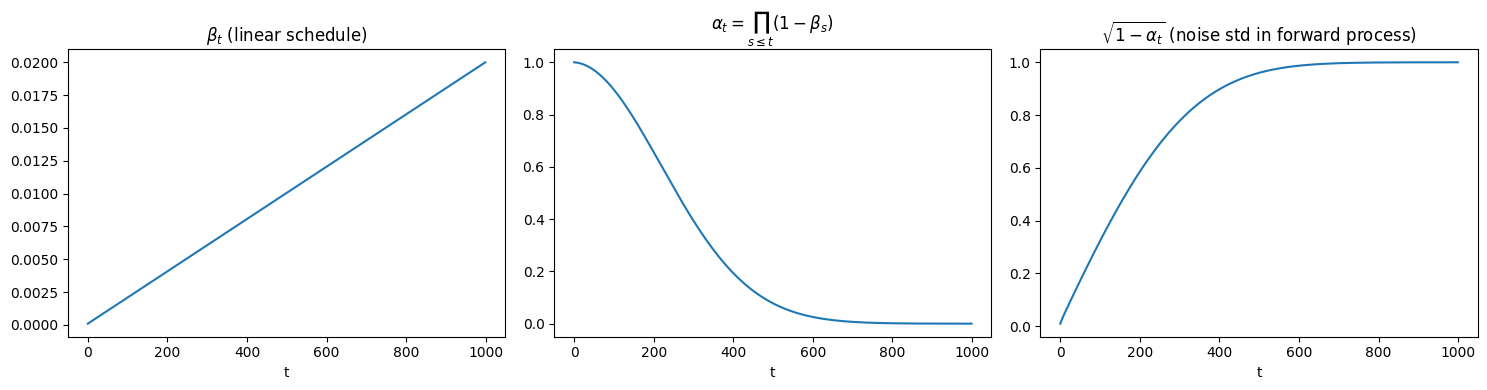

In [3]:
t_axis = np.arange(T)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t_axis, betas.numpy())
axes[0].set_title(r'$\beta_t$ (linear schedule)')
axes[0].set_xlabel('t')

axes[1].plot(t_axis, alphas.numpy())
axes[1].set_title(r'$\alpha_t = \prod_{s \leq t}(1-\beta_s)$')
axes[1].set_xlabel('t')

axes[2].plot(t_axis, (1 - alphas).sqrt().numpy())
axes[2].set_title(r'$\sqrt{1-\alpha_t}$ (noise std in forward process)')
axes[2].set_xlabel('t')

plt.tight_layout()
plt.savefig('../results/figures/01_noise_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Mathematical sanity check: η=1 must match diffusers DDPMScheduler

Song et al. 2020, Eq. 12 with η=1 and σ_t = β̃_t^{1/2} must reproduce
the DDPM ancestral sampler (Ho et al. 2020). We verify this numerically
against `diffusers.DDPMScheduler` at several timesteps.

t= 999  MAE = 6.44e-08
t= 750  MAE = 9.43e-08
t= 500  MAE = 2.75e-07
t= 250  MAE = 4.62e-08
t= 100  MAE = 6.81e-07

Max MAE across all timesteps: 6.81e-07  ✓  (threshold: 1e-4)


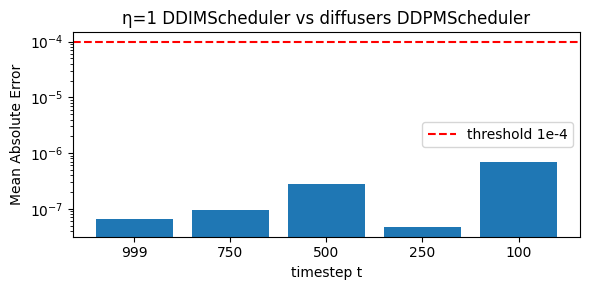

In [4]:
from diffusers import DDPMScheduler as DiffusersDDPM

ddpm_ref = DiffusersDDPM(
    num_train_timesteps=T,
    beta_start=1e-4,
    beta_end=0.02,
    beta_schedule='linear',
    clip_sample=False,
    prediction_type='epsilon',
)
ddpm_ref.set_timesteps(T)

our_scheduler = DDIMScheduler(alphas, eta=1.0)

torch.manual_seed(0)
test_timesteps = [999, 750, 500, 250, 100]
maes = []

for t in test_timesteps:
    x_t  = torch.randn(4, 3, 32, 32)
    eps  = torch.randn(4, 3, 32, 32)
    
    gen1 = torch.Generator(); gen1.manual_seed(42)
    gen2 = torch.Generator(); gen2.manual_seed(42)

    x_ours      = our_scheduler.step(eps, x_t, t=t, t_prev=t-1, generator=gen1)
    x_diffusers = ddpm_ref.step(eps, t, x_t, generator=gen2).prev_sample

    mae = (x_ours - x_diffusers).abs().mean().item()
    maes.append(mae)
    print(f't={t:4d}  MAE = {mae:.2e}')

assert all(m < 1e-4 for m in maes), f'Sanity check failed: η=1 does not match diffusers DDPMScheduler (max MAE={max(maes):.2e})'
print(f'\nMax MAE across all timesteps: {max(maes):.2e}  ✓  (threshold: 1e-4)')

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar([str(t) for t in test_timesteps], maes)
ax.axhline(1e-4, color='red', linestyle='--', label='threshold 1e-4')
ax.set_yscale('log')
ax.set_xlabel('timestep t')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('η=1 DDIMScheduler vs diffusers DDPMScheduler')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/01_sanity_eta1_vs_ddpm.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. DDIM (η=0) vs DDPM (η=1) at NFE=1000, seed A

At 1000 steps both methods should produce comparable quality images.

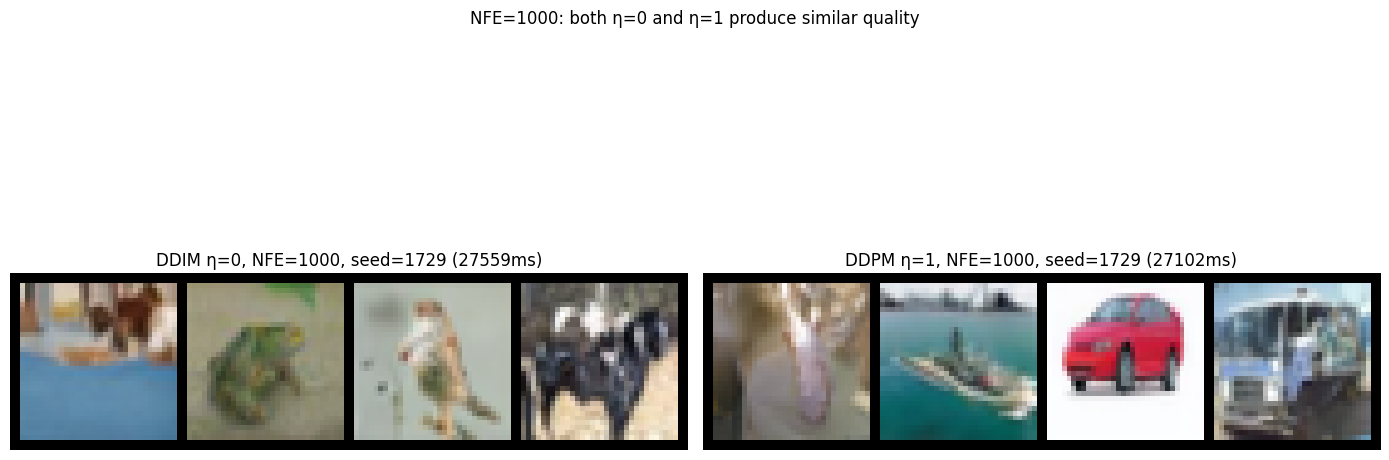

In [5]:
Path('../results/figures').mkdir(parents=True, exist_ok=True)

scheduler = DDIMScheduler(alphas)

SEED_X_T = 89                   # X_T will not change in these experiments
SEED_A = 1729        
NFE_1000 = 1000
SHAPE = (4, 3, 32, 32)

x_ddim_1000_A, t_ddim = sample(eps_fn, scheduler, SHAPE, NFE_1000, eta=0.0, seed=SEED_X_T, sampling_seed=SEED_A, device=DEVICE, dtype=DTYPE)
x_ddpm_1000_A, t_ddpm = sample(eps_fn, scheduler, SHAPE, NFE_1000, eta=1.0, seed=SEED_X_T, sampling_seed=SEED_A, device=DEVICE, dtype=DTYPE)

save_grid(x_ddim_1000_A, '../results/figures/01_ddim_eta0_nfe1000_seedA.png')
save_grid(x_ddpm_1000_A, '../results/figures/01_ddpm_eta1_nfe1000_seedA.png')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, img_path, title in zip(
    axes,
    ['../results/figures/01_ddim_eta0_nfe1000_seedA.png',
     '../results/figures/01_ddpm_eta1_nfe1000_seedA.png'],
    [f'DDIM η=0, NFE=1000, seed={SEED_A} ({t_ddim:.0f}ms)',
     f'DDPM η=1, NFE=1000, seed={SEED_A} ({t_ddpm:.0f}ms)']
):
    ax.imshow(plt.imread(img_path))
    ax.set_title(title)
    ax.axis('off')
plt.suptitle('NFE=1000: both η=0 and η=1 produce similar quality')
plt.tight_layout()
plt.savefig('../results/figures/01_comparison_nfe1000_seedA.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Determinism of DDIM vs stochasticity of DDPM (seed A vs seed B, NFE=1000)

DDIM (η=0) is deterministic: **same seed → same image**. DDPM (η=1) is stochastic.

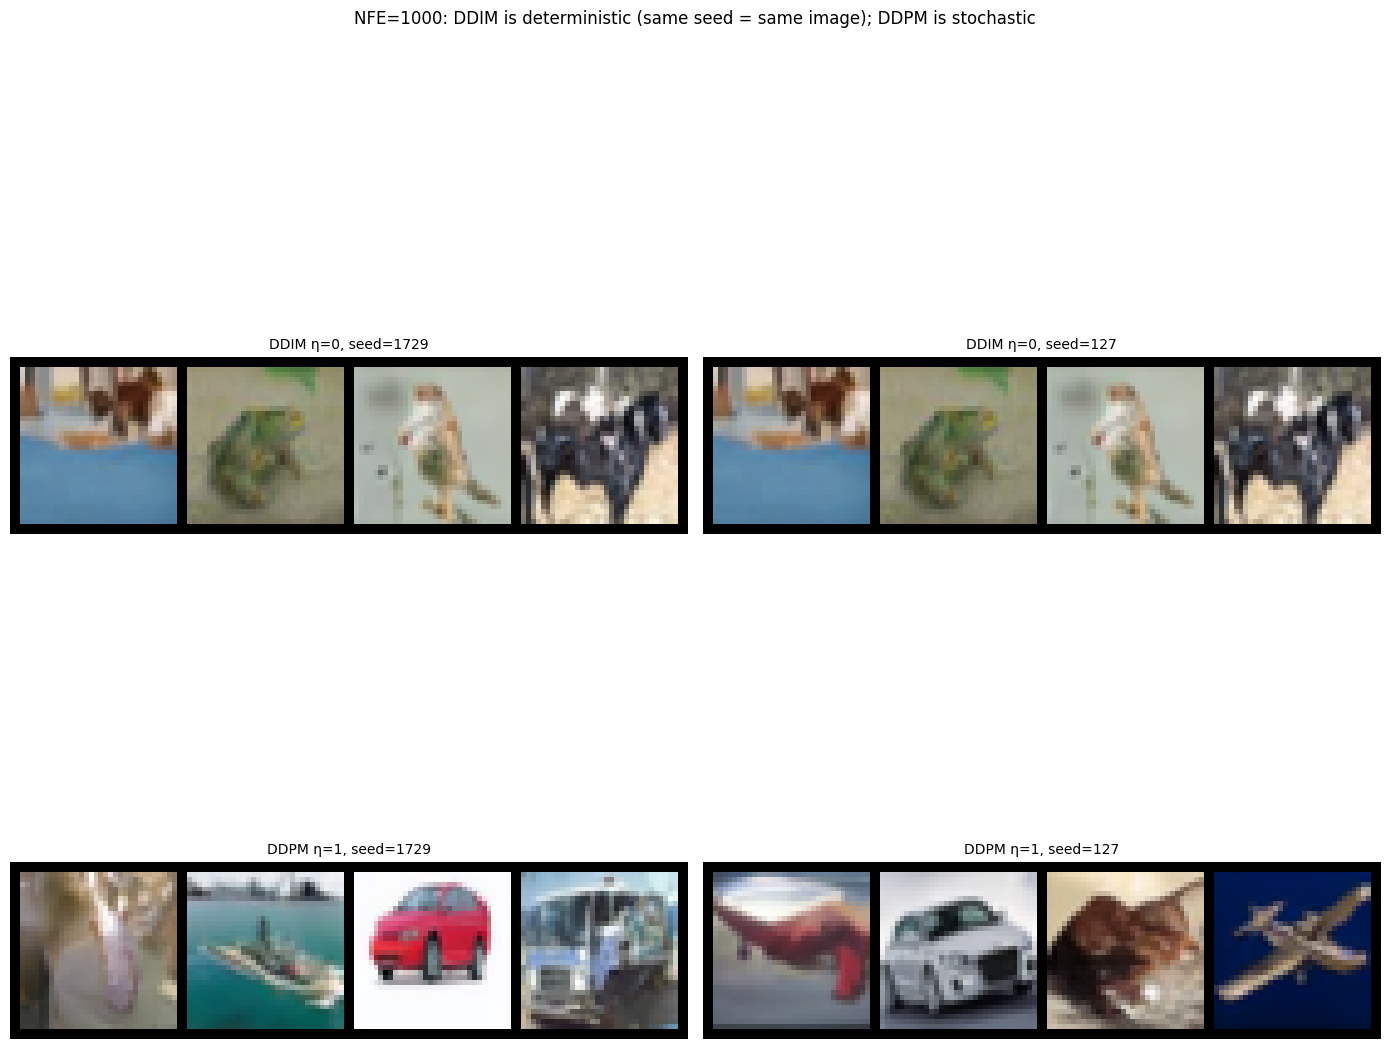

In [ ]:
SEED_B = 127

x_ddim_1000_B, _ = sample(eps_fn, scheduler, SHAPE, NFE_1000, eta=0.0, seed=SEED_X_T, sampling_seed=SEED_B, device=DEVICE, dtype=DTYPE)
x_ddpm_1000_B, _ = sample(eps_fn, scheduler, SHAPE, NFE_1000, eta=1.0, seed=SEED_X_T, sampling_seed=SEED_B, device=DEVICE, dtype=DTYPE)

# # DDIM seed A vs Seed B: Comparison to show determinism



save_grid(x_ddim_1000_B, '../results/figures/01_ddim_eta0_nfe1000_seedB.png')
save_grid(x_ddpm_1000_B, '../results/figures/01_ddpm_eta1_nfe1000_seedB.png')

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
titles = [
    f'DDIM η=0, seed={SEED_A}', f'DDIM η=0, seed={SEED_B}',
    f'DDPM η=1, seed={SEED_A}', f'DDPM η=1, seed={SEED_B}',
]
paths = [
    '../results/figures/01_ddim_eta0_nfe1000_seedA.png',
    '../results/figures/01_ddim_eta0_nfe1000_seedB.png',
    '../results/figures/01_ddpm_eta1_nfe1000_seedA.png',
    '../results/figures/01_ddpm_eta1_nfe1000_seedB.png',
]
for ax, path, title in zip(axes.flat, paths, titles):
    ax.imshow(plt.imread(path))
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.suptitle('NFE=1000: DDIM is deterministic (same seed = same image); DDPM is stochastic')
plt.tight_layout()
plt.savefig('../results/figures/01_determinism_nfe1000.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. NFE=20: DDIM quality advantage over DDPM

At low NFE, the DDPM stochastic discretization error accumulates;
DDIM (η=0) is significantly better because its deterministic ODE path
has lower truncation error.

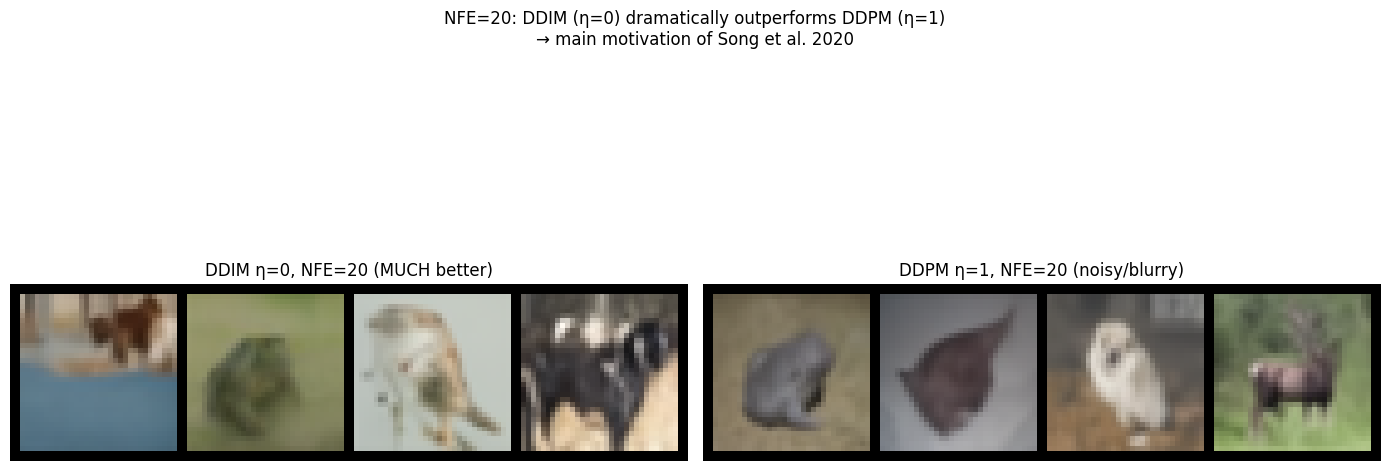

In [7]:
NFE_20 = 20

x_ddim_20, _ = sample(eps_fn, scheduler, SHAPE, NFE_20, eta=0.0, seed=SEED_X_T, sampling_seed=SEED_A, device=DEVICE, dtype=DTYPE)
x_ddpm_20, _ = sample(eps_fn, scheduler, SHAPE, NFE_20, eta=1.0, seed=SEED_X_T, sampling_seed=SEED_A, device=DEVICE, dtype=DTYPE)

save_grid(x_ddim_20, '../results/figures/01_ddim_eta0_nfe20.png')
save_grid(x_ddpm_20, '../results/figures/01_ddpm_eta1_nfe20.png')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, img_path, title in zip(
    axes,
    ['../results/figures/01_ddim_eta0_nfe20.png', '../results/figures/01_ddpm_eta1_nfe20.png'],
    ['DDIM η=0, NFE=20 (MUCH better)', 'DDPM η=1, NFE=20 (noisy/blurry)']
):
    ax.imshow(plt.imread(img_path))
    ax.set_title(title)
    ax.axis('off')
plt.suptitle('NFE=20: DDIM (η=0) dramatically outperforms DDPM (η=1)\n'
             '→ main motivation of Song et al. 2020')
plt.tight_layout()
plt.savefig('../results/figures/01_comparison_nfe20.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
ddim_diff = (x_ddim_1000_A.float() - x_ddim_1000_B.float()).abs().max().item()
print(f'DDIM seed_A vs seed_B (re-run with same X_T): max diff = {ddim_diff:.2e}  (should be 0.0)')
assert ddim_diff == 0.0, 'DDIM must be perfectly deterministic'

DDIM seed_A vs seed_B (re-run with same X_T): max diff = 0.00e+00  (should be 0.0)


## 7. Qualitative confirmation on LSUN Church 256×256

Same experiment on a 256×256 model to confirm the property is not CIFAR-10 specific.
Batch size = 4 (2×2 grid) due to memory constraints.

/home/gabriele/Desktop/Applications/Delft/Interview/project/ddim-from-ddpm/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

An error occurred while trying to fetch google/ddpm-ema-church-256: google/ddpm-ema-church-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


diffusion_pytorch_model.bin:   0%|          | 0.00/455M [00:00<?, ?B/s]

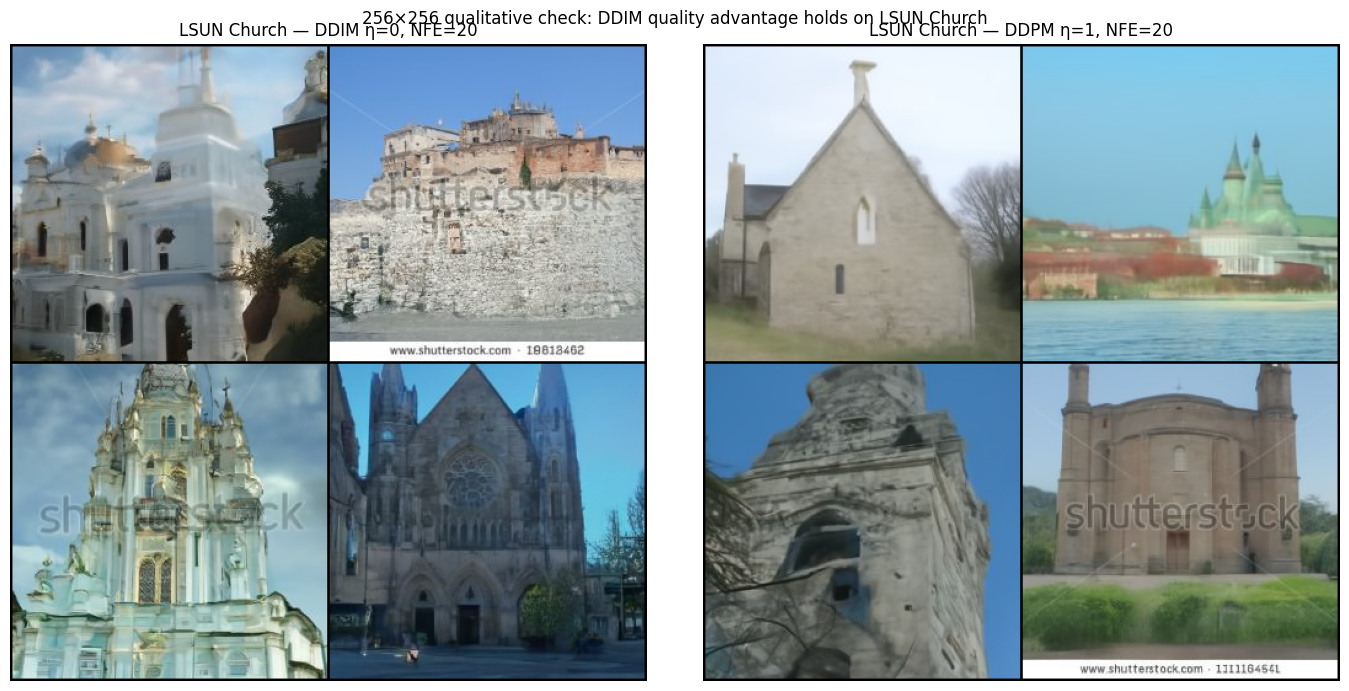

Notebook 1 complete.


In [ ]:
CHURCH_ID = 'google/ddpm-ema-church-256'
eps_fn_church, _ = load_model(CHURCH_ID, device=DEVICE, dtype=DTYPE)

SHAPE_256 = (4, 3, 256, 256)

x_church_ddim, _ = sample(eps_fn_church, scheduler, SHAPE_256, num_steps=20, eta=0.0, sampling_seed=51, seed=SEED_A, device=DEVICE, dtype=DTYPE)
x_church_ddpm, _ = sample(eps_fn_church, scheduler, SHAPE_256, num_steps=20, eta=1.0, sampling_seed=51, seed=SEED_A, device=DEVICE, dtype=DTYPE)

save_grid(x_church_ddim, '../results/figures/01_church_ddim_eta0_nfe20.png', nrow=2)
save_grid(x_church_ddpm, '../results/figures/01_church_ddpm_eta1_nfe20.png', nrow=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, img_path, title in zip(
    axes,
    ['../results/figures/01_church_ddim_eta0_nfe20.png',
     '../results/figures/01_church_ddpm_eta1_nfe20.png'],
    ['LSUN Church — DDIM η=0, NFE=20', 'LSUN Church — DDPM η=1, NFE=20']
):
    ax.imshow(plt.imread(img_path))
    ax.set_title(title)
    ax.axis('off')
plt.suptitle('256×256 qualitative check: DDIM quality advantage holds on LSUN Church')
plt.tight_layout()
plt.savefig('../results/figures/01_church_comparison.png', dpi=150, bbox_inches='tight')
plt.show()